In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [4]:
df = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

In [5]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
1575,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27786,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24187,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
26941,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
23510,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
import matplotlib.pyplot as plt

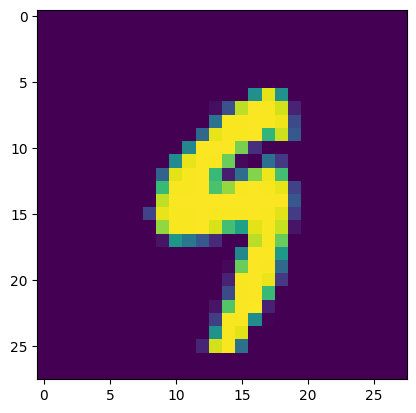

In [8]:
plt.imshow(df.iloc[9768, 1:].values.reshape(28,28))

In [9]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [11]:
X_train.shape

(33600, 784)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

In [13]:
knn = KNeighborsClassifier()

In [14]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [15]:
import time
start = time.time()
y_pred = knn.predict(X_test)
print(time.time() - start)

12.504027605056763


In [16]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9648809523809524

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [18]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=200)

In [20]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [21]:
X_train_trf.shape

(33600, 200)

In [22]:
knn = KNeighborsClassifier()

In [23]:
knn.fit(X_train_trf, y_train)

KNeighborsClassifier()

In [24]:
y_pred = knn.predict(X_test_trf)

In [25]:
accuracy_score(y_test, y_pred)

0.950595238095238

In [26]:
# for i in range(1, 785):
#     pca = PCA(n_components=200)
#     X_train_trf = pca.fit_transform(X_train)
#     X_test_trf = pca.transform(X_test)

#     knn = KNeighborsClassifier()

#     knn.fit(X_train_trf, y_train)

#     y_pred = knn.predict(X_test_trf)

#     print(accuracy_score(y_test, y_pred))

In [27]:
#transforming to a 2D coordinate system
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [28]:
X_train_trf

array([[-2.71862288, -0.4898149 ],
       [-0.67705191, -6.75364002],
       [-3.03322149,  6.50979398],
       ...,
       [ 2.14880812,  0.78060899],
       [ 1.05960332,  0.94774047],
       [17.70258779,  1.96207995]])

In [29]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                y=X_train_trf[:,1],
                color=y_train_trf,
                color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [33]:
#transforming to a 2D coordinate system
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [34]:
X_train_trf

array([[-2.71856254, -0.49002013,  1.13569468],
       [-0.67714529, -6.75339999, -2.3357182 ],
       [-3.03319938,  6.50979328,  7.49154821],
       ...,
       [ 2.14881758,  0.78099965, -0.74777307],
       [ 1.05971233,  0.94738457,  3.95008759],
       [17.70256193,  1.96187491, -4.94305745]])

In [35]:
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=X_train_trf[:,0], y=X_train_trf[:,1],
                   z=X_train_trf[:,2],
                   color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20)
)

In [36]:
pca.explained_variance_ # This are the Eigen Values

array([40.67111197, 29.17023399, 26.74459612])

In [37]:
pca.components_ # This are PCA Vectors

array([[ 6.79793317e-17,  4.25397469e-18,  1.09980992e-18, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-1.20926002e-16,  7.85794713e-18,  1.84952749e-19, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 1.17594110e-17, -8.42781216e-17, -9.37758365e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [38]:
pca.components_.shape

(3, 784)

In [41]:
pca.explained_variance_ratio_

array([0.05785192, 0.0414927 , 0.03804239])

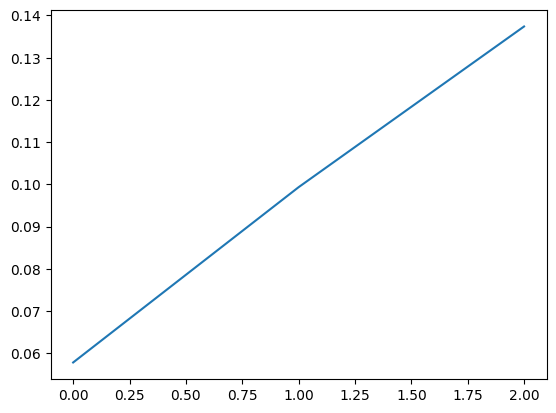

In [42]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))